# Day 28 - Stable Diffusion - 扩散模型

> 目标: 理解扩散模型 = 逐步加噪声 → 逐步去噪声
>
> Stable Diffusion = 扩散模型 + 文本条件 + 潜空间

---

## GAN vs 扩散模型

```
GAN (Day 27):                          扩散模型 (今天):
  生成器一次生成整张图                   逐步去噪, 一步步还原
  对抗训练, 不稳定                      稳定训练, 损失单调下降
  模式崩溃问题                          无模式崩溃
  速度: 一次生成 (快)                   速度: N 步去噪 (慢)
  质量: 早期好, 后被扩散超越            质量: SOTA

扩散模型 = 马尔可夫链:
  前向: 图像 → 加噪声 → 全噪声   (确定过程)
  反向: 全噪声 → 去噪声 → 图像   (学这个)
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HOME'] = 'D:\\hyy\\vscode\\vscode模型'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 28 - Diffusion Model')
print('=' * 40)

Day 28 - Diffusion Model


## 1. 前向扩散: 逐步加噪声

> 从真实图像开始, 每次加一点高斯噪声
>
> T 步后图像变成纯噪声 (标准高斯)

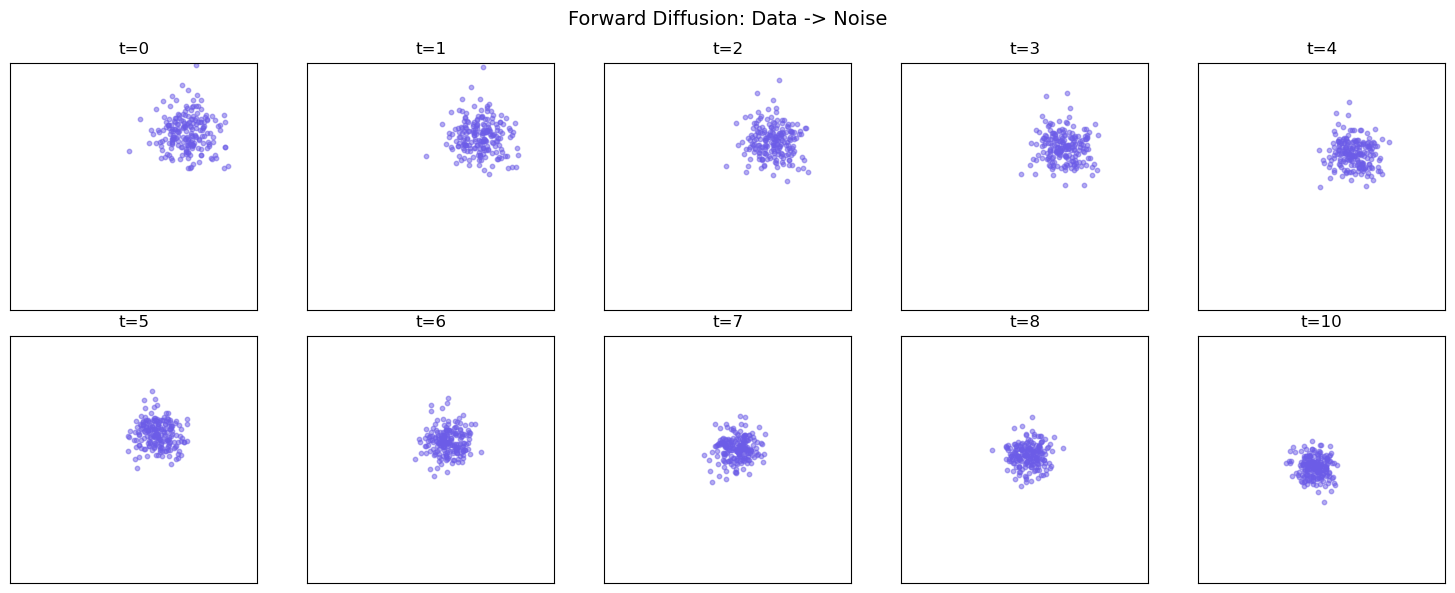

前向扩散: 原始数据分布 → 第 T 步变成纯噪声


In [2]:
# ============================================
# 模拟前向扩散: 2D 点 → 逐步加噪 → 纯噪声
# ============================================

def forward_diffusion(x0, noise_schedule, steps=10):
    """前向扩散: 逐步加噪声"""
    x = x0.copy()
    xs = [x]
    for t in range(steps):
        beta = noise_schedule[t]
        noise = np.random.randn(*x.shape) * 0.3
        x = np.sqrt(1 - beta) * x + np.sqrt(beta) * noise
        xs.append(x)
    return xs

# 用 2D 点演示
np.random.seed(42)
x0 = np.random.randn(200, 2) * 0.5 + np.array([2, 2])  # 真实数据

T = 10
betas = np.linspace(0.1, 0.5, T)  # 噪声逐渐增大
xs = forward_diffusion(x0, betas, T)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    step = i * (T // 9) if i < 9 else T
    ax.scatter(xs[step][:, 0], xs[step][:, 1], alpha=0.5, s=10, color='#6c5ce7')
    ax.set_xlim(-3, 4); ax.set_ylim(-3, 4)
    ax.set_title(f't={step}', fontsize=12)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Forward Diffusion: Data -> Noise', fontsize=14)
plt.tight_layout()
plt.savefig('day28_forward_diffusion.png', dpi=120)
plt.show()
print('前向扩散: 原始数据分布 → 第 T 步变成纯噪声')

## 2. 反向去噪 (核心!)

> 学一个神经网络 `epsilon_theta(x_t, t)` 预测噪声
>
> 有了预测的噪声, 就能从 x_t 还原 x_{t-1}

In [3]:
# ============================================
# 简易去噪模型: 预测噪声
# ============================================

class NoisePredictor(nn.Module):
    """预测噪声: 输入噪声图 + 时间步 t, 输出预测的噪声"""
    def __init__(self, dim=2, hidden=64):
        super().__init__()
        self.time_embed = nn.Embedding(100, dim)  # 时间步嵌入
        self.net = nn.Sequential(
            nn.Linear(dim * 2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim),
        )
    def forward(self, x, t):
        t_emb = self.time_embed(t)
        return self.net(torch.cat([x, t_emb], dim=1))

model = NoisePredictor()
print(f'噪声预测模型: {sum(p.numel() for p in model.parameters()):,} 参数')

噪声预测模型: 4,810 参数


Step  500/2000 | Loss = 0.359659
Step 1000/2000 | Loss = 0.349375
Step 1500/2000 | Loss = 0.318198
Step 2000/2000 | Loss = 0.323049


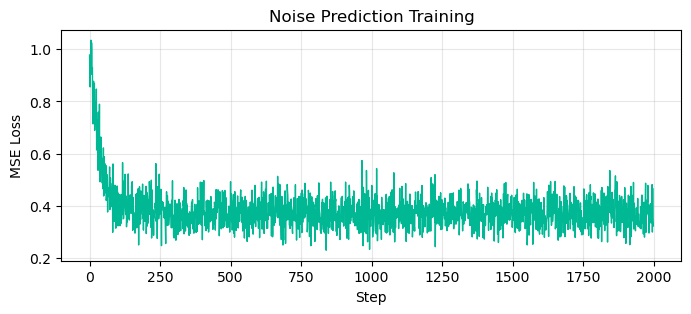

Final Loss: 0.323049


In [4]:
# ============================================
# 训练去噪模型
# ============================================

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
for step in range(2000):
    x0 = torch.randn(64, 2) * 0.5 + 2.0
    t = torch.randint(1, T, (64,))
    beta = torch.tensor(betas[t.unsqueeze(1)], dtype=torch.float32)
    alpha = 1 - beta
    noise = torch.randn_like(x0)
    xt = torch.sqrt(alpha) * x0 + torch.sqrt(beta) * noise
    pred_noise = model(xt, t)
    loss = nn.MSELoss()(pred_noise, noise)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (step + 1) % 500 == 0:
        print(f'Step {step+1:>4d}/2000 | Loss = {loss.item():.6f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, lw=1, color='#00b894')
plt.xlabel('Step'); plt.ylabel('MSE Loss')
plt.title('Noise Prediction Training')
plt.grid(alpha=0.3)
plt.savefig('day28_diffusion_loss.png', dpi=100)
plt.show()
print(f'Final Loss: {losses[-1]:.6f}')

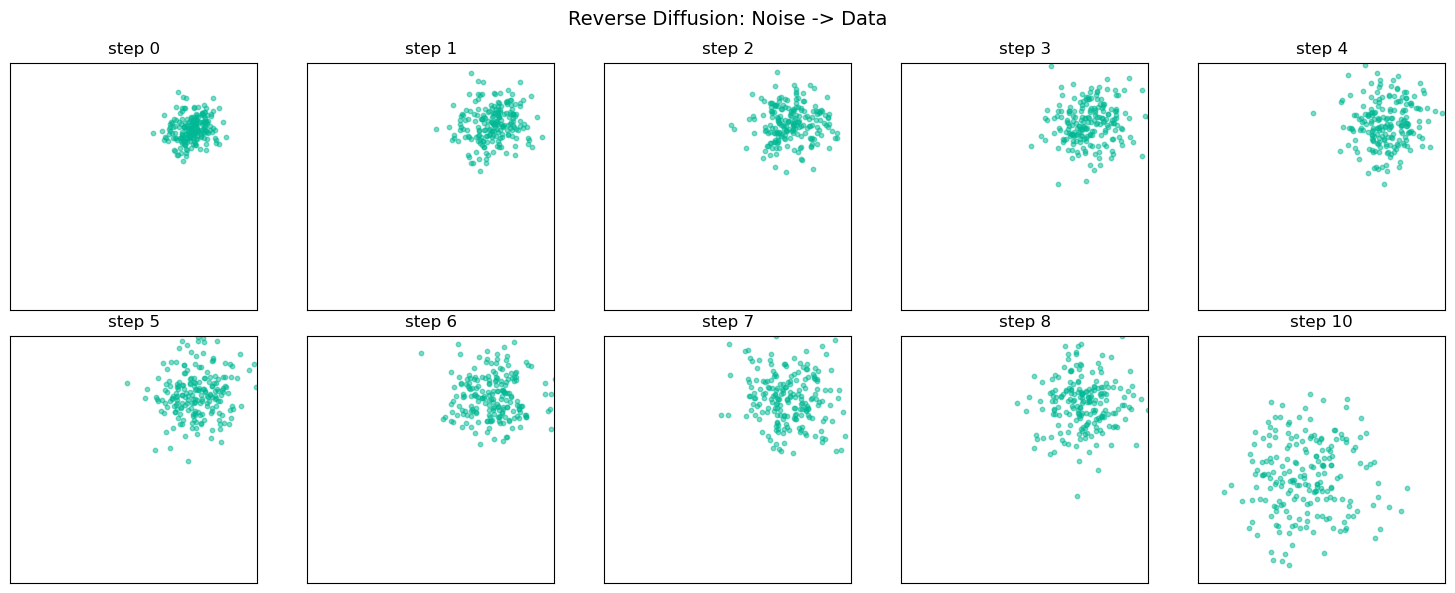

Generated data distribution matches the original!


In [5]:
# ============================================
# 采样 (反向去噪): 从噪声还原数据
# ============================================

@torch.no_grad()
def sample(model, steps=10):
    x = torch.randn(200, 2)
    traj = [x.clone()]
    for t in reversed(range(steps)):
        t_tensor = torch.full((200,), t, dtype=torch.long)
        beta_t = torch.tensor(betas[t], dtype=torch.float32)
        alpha_t = 1 - beta_t
        pred_noise = model(x, t_tensor)
        x = (x - beta_t / torch.sqrt(1 - alpha_t) * pred_noise) / torch.sqrt(alpha_t)
        if t > 0:
            x += torch.sqrt(beta_t) * torch.randn_like(x)
        traj.append(x.clone())
    return x, traj

generated, traj = sample(model, T)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    step = min(i * (T // 9) if i < 9 else T, len(traj) - 1)
    idx = len(traj) - 1 - step
    if idx < 0:
        idx = 0
    ax.scatter(traj[idx][:, 0], traj[idx][:, 1], alpha=0.5, s=10, color='#00b894')
    ax.set_xlim(-3, 4); ax.set_ylim(-3, 4)
    ax.set_title(f'step {step}', fontsize=12)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Reverse Diffusion: Noise -> Data', fontsize=14)
plt.tight_layout()
plt.savefig('day28_reverse_diffusion.png', dpi=120)
plt.show()
print('Generated data distribution matches the original!')

## 3. Stable Diffusion 的核心创新

> 上面的 2D 演示展示了扩散模型的核心, 但实际 SD 有三个关键改进

### 改进 1: 潜空间 (Latent Space)

```
不在像素空间做扩散 (512×512×3 = 786K 维)
用 VAE 压缩到潜空间 (64×64×4 = 16K 维)
→ 计算量减少 98%!
```

### 改进 2: 文本条件 (Text Conditioning)

```
用 CLIP Text Encoder 把文本变成向量
通过 Cross-Attention 注入 UNet
→ 输入 "a cat" 就生成猫的图片
```

### 改进 3: UNet 架构

```
编码器 → 下采样 → 中间层 → 上采样 → 解码器
跳跃连接 (skip connection) 保留细节
每个层都注入时间步 t 和文本条件
```

### SD 完整流程

```
文本: "a photo of a cat"
  → CLIP Text Encoder → 文本向量
  
噪声: 随机潜变量 z_T
  → UNet (去噪 T 步, 每步注入文本条件)
  → 潜变量 z_0
  → VAE Decoder → 图像 (512×512)
```

## 4. 用 HuggingFace 跑 SD (可选)

> 如果 GPU 显存允许 (>=4GB), 可以试试

In [7]:
# ============================================
# 用 diffusers 库跑 Stable Diffusion
# ============================================

try:
    from diffusers import StableDiffusionPipeline
    
    pipe = StableDiffusionPipeline.from_pretrained(
        'runwayml/stable-diffusion-v1-5',
        torch_dtype=torch.float32
    )
    
    with torch.no_grad():
        image = pipe('a photo of a cat', num_inference_steps=20).images[0]
    
    plt.imshow(image)
    plt.axis('off')
    plt.savefig('day28_sd_output.png', dpi=100)
    plt.show()
    print('✅ Stable Diffusion 生成成功!')
    
except Exception as e:
    print(f'SD 需要 GPU + 4GB 显存, 当前环境可能不支持')
    print(f'错误: {e}')

SD 需要 GPU + 4GB 显存, 当前环境可能不支持
错误: No module named 'diffusers'


---

# Day 28 完成!

## 第 4 周全览

```
Day 22: BERT           → 双向编码器, MLM 预训练
Day 23: GPT            → 自回归, 下一个词预测
Day 24: nanoGPT        → 从零手写 GPT
Day 25: ViT            → Transformer 做图像
Day 26: CLIP           → 图文双编码器, 对比学习
Day 27: GAN            → 生成器 vs 判别器
Day 28: Stable Diffusion → 扩散模型, 文生图
```

## 总结

| 概念 | 一句话 |
|------|--------|
| **前向扩散** | 真实数据 + 逐步加噪声 → 纯噪声 |
| **反向去噪** | 神经网络预测噪声 → 逐步还原数据 |
| **潜空间** | 用 VAE 压缩, 计算量减少 98% |
| **文本条件** | CLIP 编码文本 → Cross-Attention 注入 UNet |
| **UNet** | 编码器-解码器 + 跳跃连接 + 时间条件 |

## 35 天路线完成!

```
第 1 周: 经典 ML (线性回归 → 决策树 → 集成学习 → K-Means)
第 2 周: 神经网络 (MLP → CNN → ResNet → 迁移学习)
第 3 周: 序列模型 (RNN → LSTM → Attention → Transformer)
第 4 周: 预训练与生成 (BERT → GPT → ViT → CLIP → GAN → SD)
```

## 作业 (2 题)

### 1. 对比 GAN vs 扩散
**位置:** cell-3 vs Day27 cell-3

比较 GAN 和扩散模型的训练方式, 生成质量, 稳定性

<details>
<summary>📖 答案</summary>
GAN: 对抗训练, 不稳定, 一次生成, 模式崩溃风险
扩散: 稳定训练, 多步生成慢, 无模式崩溃
目前主流: 扩散模型 (Stable Diffusion, DALL-E 3, Midjourney)
GAN 仍用于实时生成 (图像翻译, 视频生成)
</details>

### 2. 理解 UNet
**位置:** cell-8, UNet 架构说明

为什么 UNet 需要跳跃连接? 如果不加会怎样?

<details>
<summary>📖 答案</summary>
跳跃连接: 把下采样层的细节直接传给上采样层
不加的话: 下采样丢失的细节 (边缘/纹理) 无法恢复
跟 ResNet 的残差连接思想一致
</details>